In [1]:
import os
print(os.getcwd())

/home/alesau/mllm/mllm


In [8]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo
from configuration_template import Config

config = Config()
config.input_type = 'simple'
config.task = 'grid'

img_kwargs = {
    "patch_size": config.patch_size*3,
    "patch_padding": config.grid_padding,
    "patch_pad_color": config.grid_pad_color,
}

generate_kwargs = {
        "max_new_tokens": config.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}


print("Model ID: ", config.model_id)



model_version: Qwen2
model_type: Qwen
Model ID:  Qwen/Qwen2-VL-2B-Instruct


In [3]:
Model = Qwen
model = Model(config.model_id, **model_kwargs)
print(f'Model: {model.__class__}')

building Qwen model...


Loading weights: 100%|██████████| 729/729 [00:10<00:00, 67.37it/s] 
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: <class 'models.mllm_wrappers.Qwen'>


In [4]:
## set randomness
model_mode = 'random'

if model_mode == 'random':
    ## set randomness
    model.model.generation_config.temperature = 0.7
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.9
    model.model.generation_config.top_k = 50
else:
    ## set deterministic
    model.model.generation_config.temperature = 0.01
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.001
    model.model.generation_config.top_k = 1



In [31]:
# define prompts
TOP_INSTRUCTION = 'In this image you can see three color grids. In the following dialogue, the speaker will describe exactly one of the grids. Please indicate to me whether he refers to the left, middle or right grid.'
BOTTOM_PROMPT = 'Is it the left, middle or right grid?'


##Prompt 1
#SPEAKER_PROMPT_ONE = 'In this image you can see three color grids. Describe the'
#SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as left, middle or right.'


##Prompt 2
SPEAKER_PROMPT_ONE = 'In this image you can see three color grids. Describe the'
SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as left, middle or right. Do not describe the whole grid, if not necessary. You can also just describe one or two objects in the grid, if that is sufficient to identify it. Focus on the most distinctive features of the grid.'

SPEAKER_PROMPT_ONE = 'In this image you can see three colors. Describe the highlighted color in such a way, that I can identify it among the three colors. The color you should describe will be surrounded by a bright green border. Do not refer to the color as left, middle or right. Do not mention the green border. Do not mention any location at all.'
SPEAKER_PROMPT_TWO = ''

SPEAKER_PROMPT_ONE = 'In this image you can see three colors. Describe the color, which is defined throught the following coordinates: '
SPEAKER_PROMPT_TWO = '. I see the three colors in a different order than you do and i dont know which one you should describe. Describe the defined color in such a way, that I can identify it among the three colors. Do not refer to the color as left, middle or right. Do not mention any location or coordinates at all. Just describe the needed color. If necessary, you can also describe whats distinctive about the other colors.'


In [6]:
import pandas as pd
import os.path as osp
data_df = pd.read_json(osp.join(config.data_dir, "color_patch_data.json"))
new_responses = []
old_responses = []

Entry 46956
identifier                                                   8762-f:16
gameid                                                          8762-f
roundNum                                                            16
condition                                                        split
success                                                           True
hls_values                 [[35, 50, 84], [37, 50, 65], [315, 50, 84]]
s_order_t_distr1_distr2                                      [0, 1, 2]
l_order_t_distr1_distr2                                      [0, 1, 2]
conversation                          [[speaker, bright orange, None]]
n_utterances                                                         1
Name: 46956, dtype: object
Img Size:  (1050, 350)
s_order_t_distr1_distr2: [0, 1, 2]
Full prompt: In this image you can see three colors. Describe the color, which is defined throught the following coordinates:  [[25,25],[325,325]] . I see the three colors in a different order 

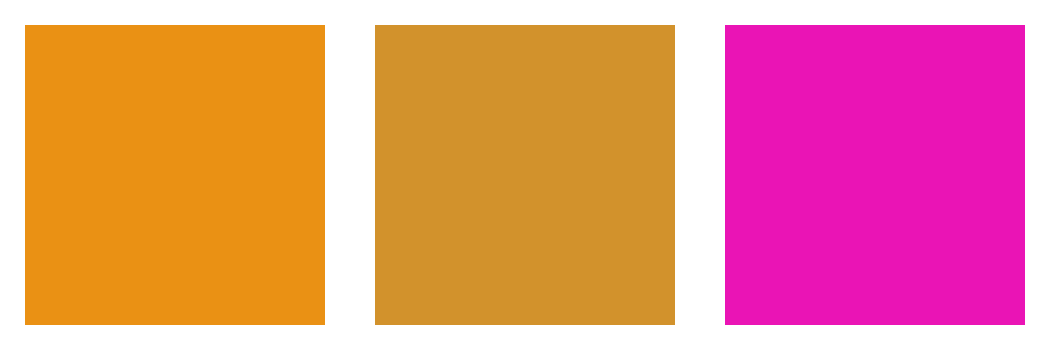

Position described by speaker: left
Response sentence: The color in the first quadrant is a vibrant orange, with a high contrast against the white background. The color is bright and lively, reminiscent of a sunny day or a bright orange fruit. In contrast, the color in the second quadrant is a warm beige, which has a slightly muted and earthy tone. The color is more neutral and less vibrant than the orange. Finally, the color in the third quadrant is a bright pink, with a strong contrast against the white background. The color is vibrant and lively, reminiscent of a sunny day or a bright pink flower. 


Entry 21163
identifier                                                         9709-7:24
gameid                                                                9709-7
roundNum                                                                  24
condition                                                              close
success                                                              

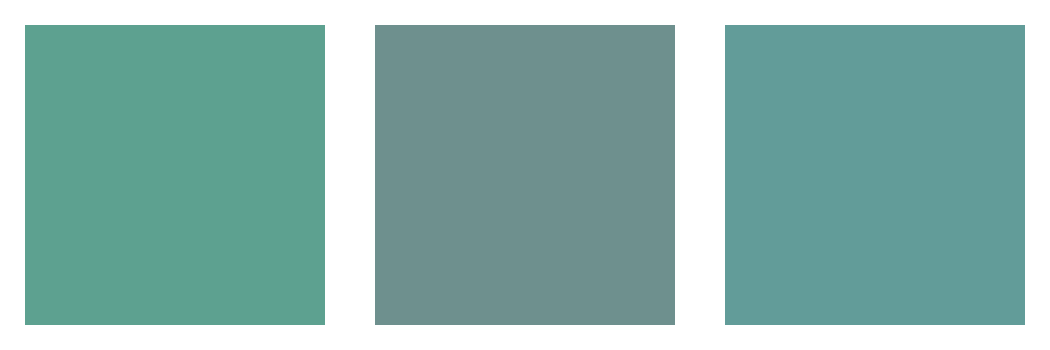

Position described by speaker: middle
Response sentence: The color described is a medium blue-grey with a slight brownish tint. It appears to be a muted shade of teal or aqua, but with a darker hue, giving it a more earthy feel. This color is not as bright or vibrant as the other two, but it does provide a calming and subdued contrast to the other two colors. 


Entry 38273
identifier                                                    8547-9:5
gameid                                                          8547-9
roundNum                                                             5
condition                                                          far
success                                                           True
hls_values                 [[198, 50, 67], [73, 50, 71], [16, 50, 73]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2                                      [1, 2, 0]
conversation                                   [[speake

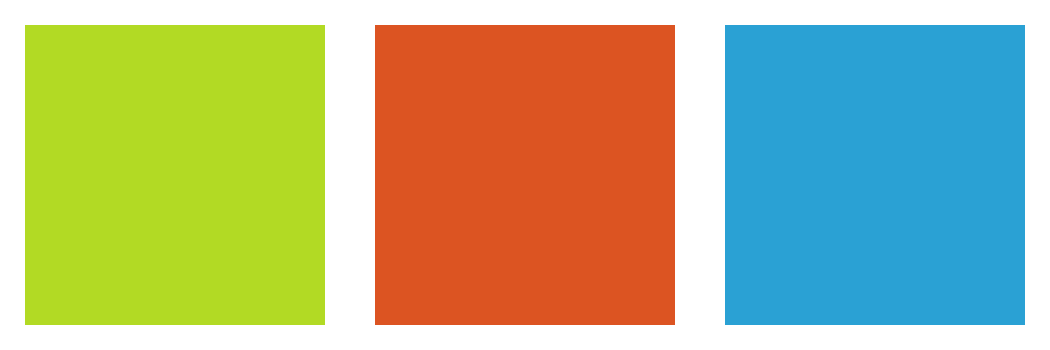

Position described by speaker: right
Response sentence: The color in the coordinates [725,25] is yellow-green. It stands out in contrast to the other two colors, which are orange and blue. The yellow-green color is bright and vibrant, resembling the color of a lemon or a bright banana. 


Entry 31799
identifier                                                  6327-c:30
gameid                                                         6327-c
roundNum                                                           30
condition                                                         far
success                                                          True
hls_values                 [[7, 50, 62], [111, 50, 80], [28, 50, 99]]
s_order_t_distr1_distr2                                     [1, 0, 2]
l_order_t_distr1_distr2                                     [1, 0, 2]
conversation                                   [[speaker, Red, None]]
n_utterances                                                        

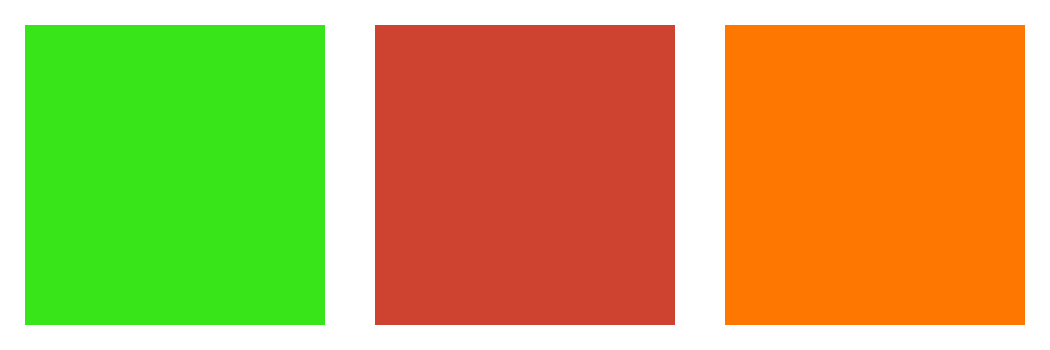

Position described by speaker: middle
Response sentence: The color you describe is a warm red shade. It has a higher saturation compared to the green and orange colors in the image. The contrast is stronger, making the red color stand out more from the green and orange hues. 


Entry 45025
identifier                                                   4893-9:33
gameid                                                          4893-9
roundNum                                                            33
condition                                                        split
success                                                           True
hls_values                 [[317, 50, 19], [339, 50, 76], [29, 50, 3]]
s_order_t_distr1_distr2                                      [1, 2, 0]
l_order_t_distr1_distr2                                      [1, 0, 2]
conversation                                  [[speaker, mauve, None]]
n_utterances                                                         1

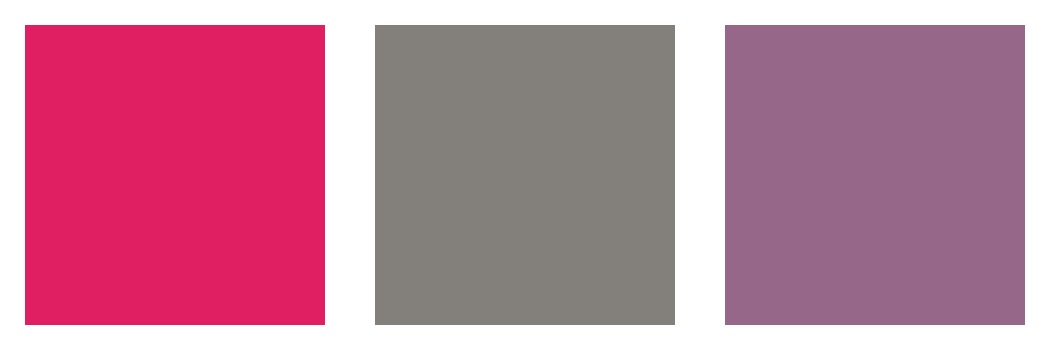

Position described by speaker: right
Response sentence: The color you are describing is a dark gray or slate gray. It has a neutral tone with a slight grayish tint, which makes it distinct from the other two colors. It is not as vibrant or eye-catching as the first color, which is a bright pink, and it is less contrasty than the third color, which is a deep purple. 


Entry 40841
identifier                                                     3159-0:34
gameid                                                            3159-0
roundNum                                                              34
condition                                                          close
success                                                             True
hls_values                    [[167, 50, 1], [65, 50, 21], [119, 50, 3]]
s_order_t_distr1_distr2                                        [2, 1, 0]
l_order_t_distr1_distr2                                        [0, 2, 1]
conversation               [[spea

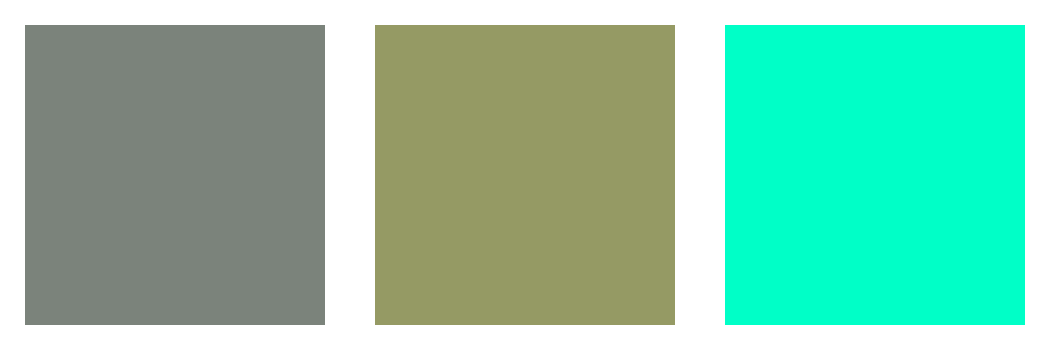

Position described by speaker: right
Response sentence: The color described as [[725,25],[1025,325]] appears to be a gradient that transitions from a dark gray at the top to a bright green at the bottom. This gradient is quite distinct from the other two colors, which are solid shades of gray and teal. 


Entry 36126
identifier                                                      8535-b:2
gameid                                                            8535-b
roundNum                                                               2
condition                                                          close
success                                                            False
hls_values                 [[236, 50, 76], [281, 50, 55], [274, 50, 93]]
s_order_t_distr1_distr2                                        [1, 0, 2]
l_order_t_distr1_distr2                                        [2, 1, 0]
conversation                               [[speaker, royal blue, None]]
n_utterances            

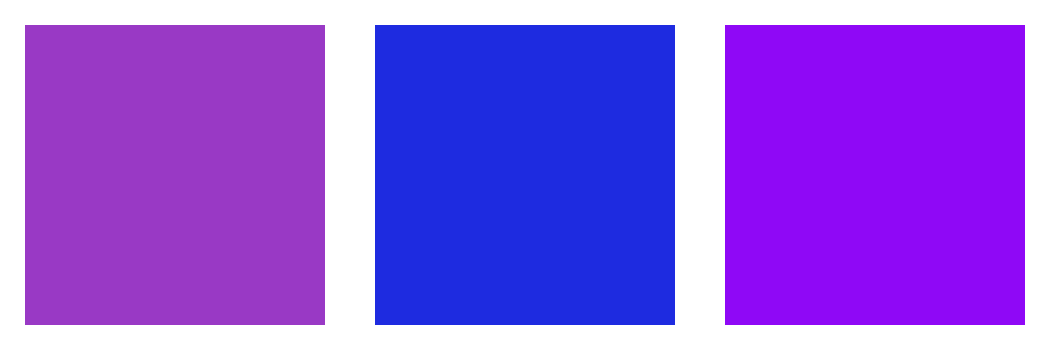

Position described by speaker: middle
Response sentence: The color in the specified coordinates is a vibrant blue. It stands out prominently against the other two colors, which are a soft lavender and a deep purple. The blue color is cooler and more saturated, while the other two colors are warmer and less saturated. 


Entry 13108
identifier                                                    2580-b:16
gameid                                                           2580-b
roundNum                                                             16
condition                                                           far
success                                                            True
hls_values                 [[333, 50, 89], [309, 50, 7], [279, 50, 49]]
s_order_t_distr1_distr2                                       [1, 2, 0]
l_order_t_distr1_distr2                                       [0, 2, 1]
conversation                                    [[speaker, pink, None]]
n_utterances      

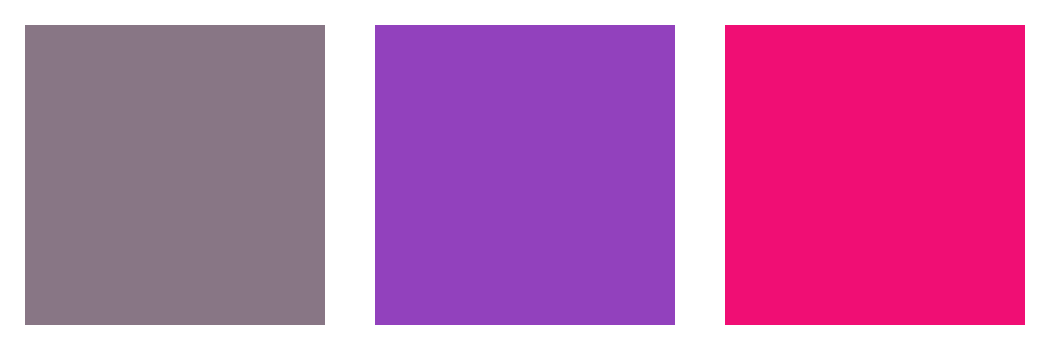

Position described by speaker: right
Response sentence: The color in the specified coordinates, which is [725, 25] to [1025, 325], is a vibrant shade of red. It stands out distinctly from the gray and purple colors, which are more muted. The red color is the most contrasting in terms of both hue and saturation, making it easily identifiable among the three. 


Entry 44344
identifier                                                     5958-d:2
gameid                                                           5958-d
roundNum                                                              2
condition                                                         close
success                                                           False
hls_values                 [[235, 50, 25], [302, 50, 8], [300, 50, 22]]
s_order_t_distr1_distr2                                       [1, 2, 0]
l_order_t_distr1_distr2                                       [0, 2, 1]
conversation                             [[speake

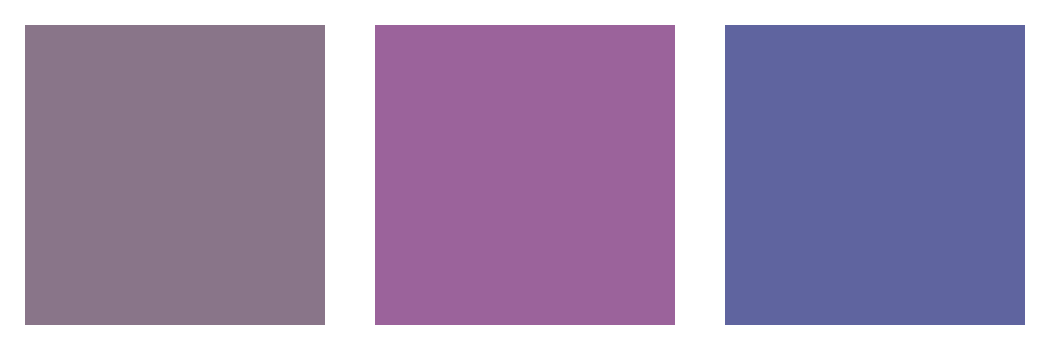

Position described by speaker: right
Response sentence: The color in the specified coordinates is a light purple. It contrasts with the other two colors by being slightly darker and less saturated. 


Entry 5657
identifier                                                    4490-3:9
gameid                                                          4490-3
roundNum                                                             9
condition                                                        split
success                                                           True
hls_values                 [[47, 50, 90], [61, 50, 67], [163, 50, 93]]
s_order_t_distr1_distr2                                      [1, 0, 2]
l_order_t_distr1_distr2                                      [1, 2, 0]
conversation                      [[speaker, school bus yellow, None]]
n_utterances                                                         1
Name: 5657, dtype: object
Img Size:  (1050, 350)
s_order_t_distr1_distr2: [1, 

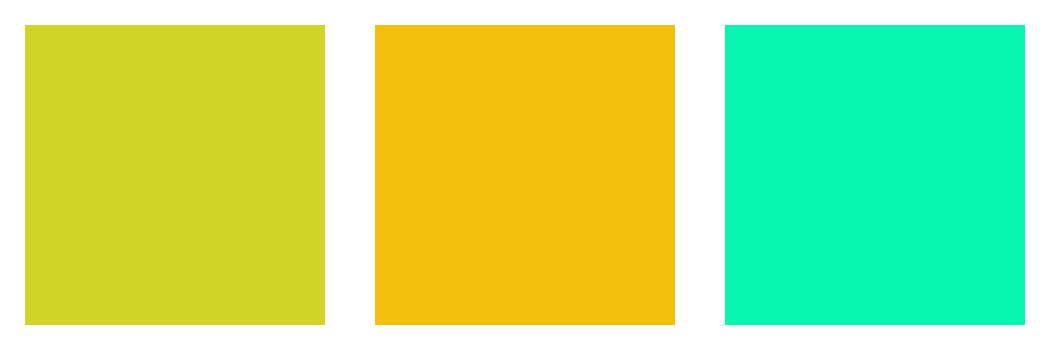

Position described by speaker: middle
Response sentence: The color you described is a vibrant yellowish-green. It stands out from the other two colors because it has a higher contrast with the brighter green of the first and the blue of the third. The first color is a deeper green, the second is a bright orange, and the third is a clear cyan. 




In [29]:
from data_prep.data_utils import build_patch_image_with_target_highlight

for i, entry in data_df.sample(n=10, random_state=42).iterrows():
    print(f"Entry {i}")
    print(entry)
    img = build_patch_image_with_target_highlight(entry.hls_values, entry.s_order_t_distr1_distr2, **img_kwargs, highlight_target=False)
    print("Img Size: ", img.size)

    if(entry.s_order_t_distr1_distr2[0] == 0):
        bounding_box ="[[25,25],[325,325]]"
    elif(entry.s_order_t_distr1_distr2[1] == 0):
        bounding_box ="[[375,25],[675,325]]"
    elif(entry.s_order_t_distr1_distr2[2] == 0):
        bounding_box ="[[725,25],[1025,325]]"

    position = ""
    print(f"s_order_t_distr1_distr2: {entry.s_order_t_distr1_distr2}")
    entry.target = entry.s_order_t_distr1_distr2.index(0)
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, bounding_box, SPEAKER_PROMPT_TWO])
    print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

In [9]:
####Qwen2-VL-2B-Instruct


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Entry 46956


AttributeError: 'Series' object has no attribute 'objs'

Qwen3-VL-2B-Instruct
Entry 2271


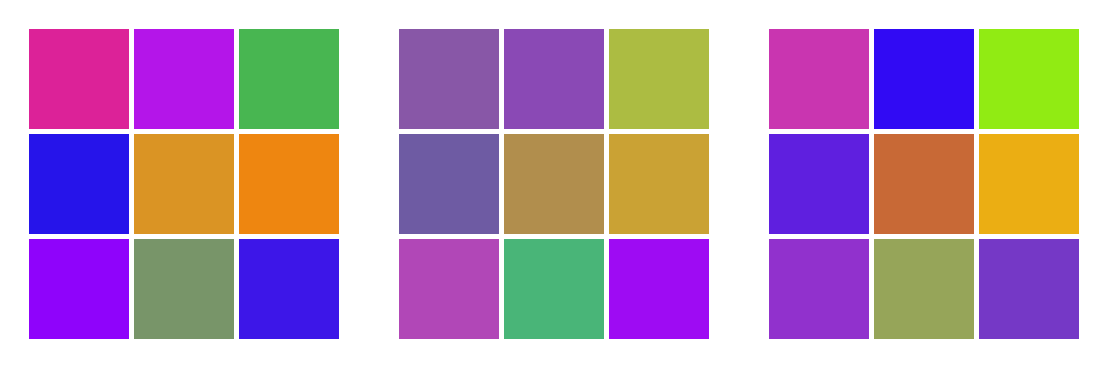

Position described by speaker: left
Response sentence: The leftmost grid has the most distinct visual characteristics. It is the only grid that contains a single object of a color that is not a standard color. This object is a purple square that stands out due to its vibrant hue, which contrasts with the other colors in the grid. The grid is composed of three rows and four columns, with a total of twelve squares. The other grids have different color schemes and patterns. The second grid has a greenish-yellow color, and the third grid has a combination of colors including purple, blue, and yellow. The left grid's distinct feature is the presence of this single, non-standard colored square. 


Entry 8698


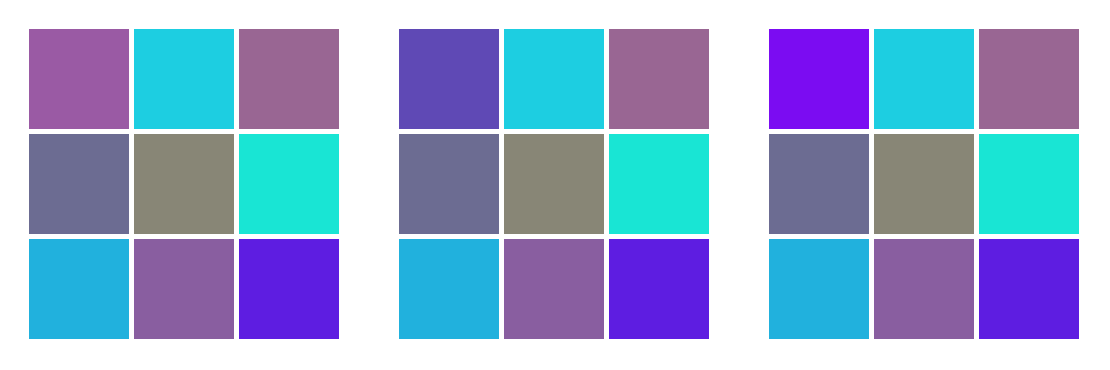

Position described by speaker: left
Response sentence: The left grid is distinguished by its use of two primary colors: a bright teal and a muted purple. It features a layout with five vertical columns and three rows. The most notable feature is the presence of two vertical columns with a single, bright teal color, which stands out due to its brightness against the purple background. The overall pattern is structured with these teal and purple blocks arranged in a grid. 


Entry 3753


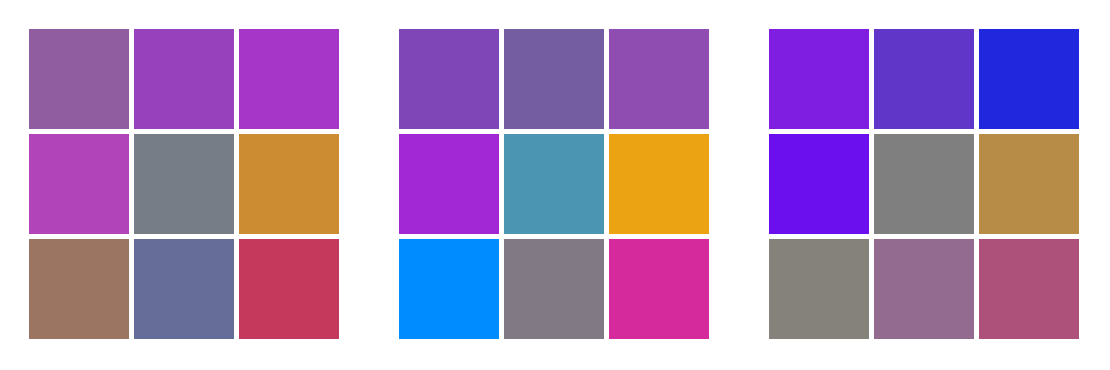

Position described by speaker: right
Response sentence: The rightmost grid is distinguished by its color scheme and the presence of a prominent blue square. Specifically, the grid contains a single blue square, which is the most visually distinct element among the three. This blue square is located in the top row, in the center of the grid, and is positioned directly above the rest of the squares. This unique placement and color make it stand out. Additionally, the grid has a total of 12 squares, which is consistent with the other two grids, but the blue square is the most distinctive feature. The other two grids have a different color scheme, with the middle grid featuring a yellow square, and the left grid featuring a pink square. Therefore, the right grid is identified by the presence of the 


Entry 8665


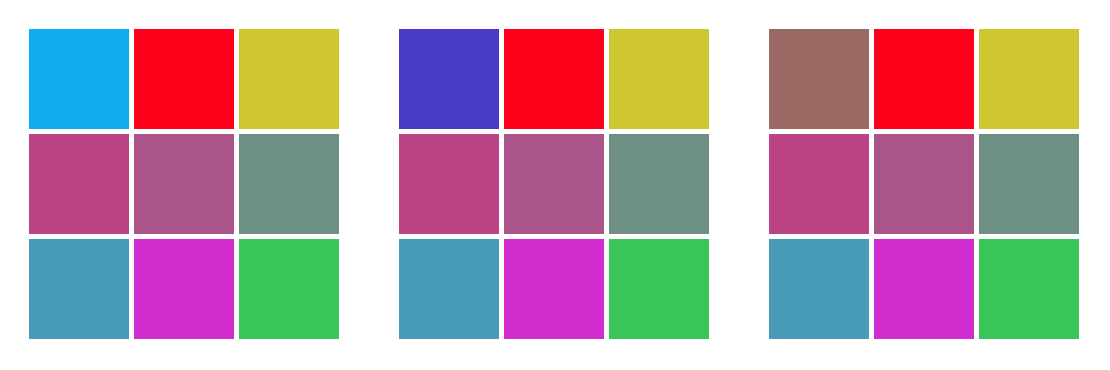

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its top row containing three bright red squares, which are noticeably more vibrant than the other colors. The grid is also characterized by a blue square in the second row, located at the far left, which stands out due to its distinct color and position. Additionally, the middle of the grid contains a prominent purple square, which is more vivid than the other colors, and is located in the second row, further distinguishing it from the others. These features—specific colors and their positions—help identify the left grid. 


Entry 4441


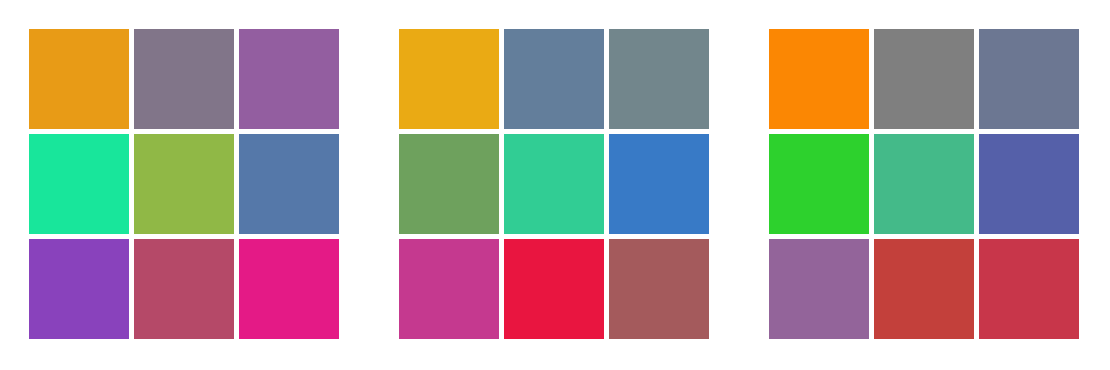

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its arrangement of colors and the presence of a prominent, centrally located yellowish-orange square. This square is positioned in the upper row and appears to be the most dominant color in the grid. The grid also contains other squares, with one in the lower row being a bright pink, which contrasts with the other colors. The overall composition is distinct, with a notable emphasis on the yellowish-orange square, making it a key identifier for the left grid. 




In [7]:
####Qwen3-VL-2B-Instruct
print("Qwen3-VL-2B-Instruct")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-0.8B
Entry 2271


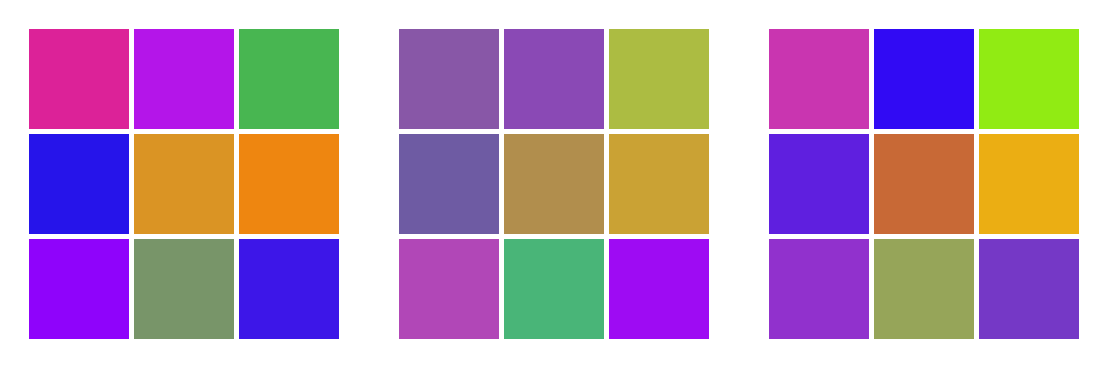

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The leftmost grid is composed of nine squares arranged in a 3x3 layout. Each square contains a distinct color and a specific geometric shape. The top row features a pink square with a star shape, a purple square with a heart shape, and a green square with a lightning bolt shape. The middle row displays an orange square with a circle, a purple square with a heart shape, and a brown square with a circle. The bottom row contains a blue square with a circle, a purple square with a heart shape, and a pink square with a circle. The distinctive features of this grid include the variety of shapes and colors, the even distribution of shapes within each square, and the distinct arrangement of the colors.
 


Entry 8698


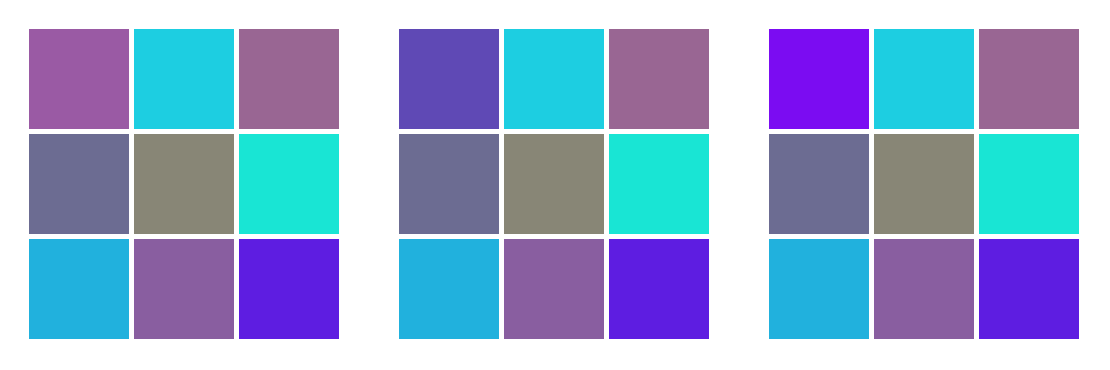

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of four distinct colored squares arranged in a 2x2 structure.

- **Top-left square**: A medium-purple square.
- **Bottom-left square**: A medium-blue square.
- **Top-right square**: A medium-light blue-green square.
- **Bottom-right square**: A medium-dark purple square.

These colors and positions are highly distinct and help distinguish this grid from the others.
 


Entry 3753


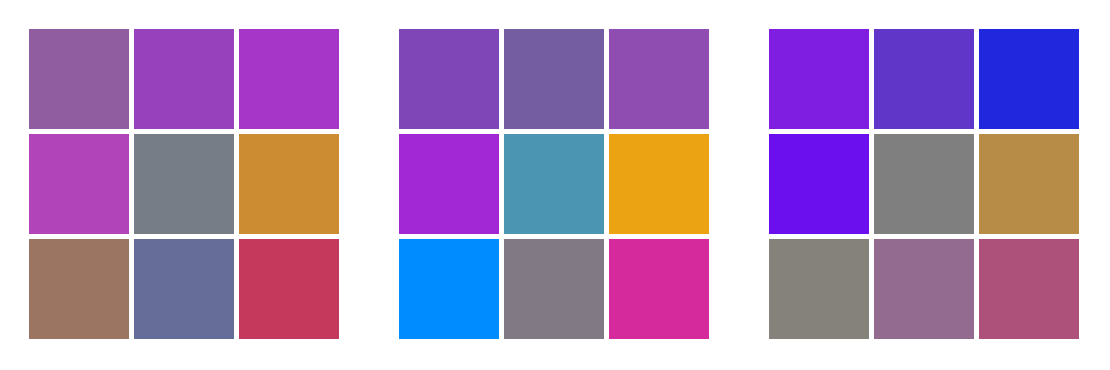

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The rightmost grid is a 3x6 grid of colorful squares, each square representing a unique color. The squares are arranged in rows and columns, and each square has a distinct color. The colors are: purple, blue, blue, blue, red, blue, blue, blue, purple, blue, blue, blue, blue, blue, purple, purple, red, red, red, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, blue, purple, red, red, blue 


Entry 8665


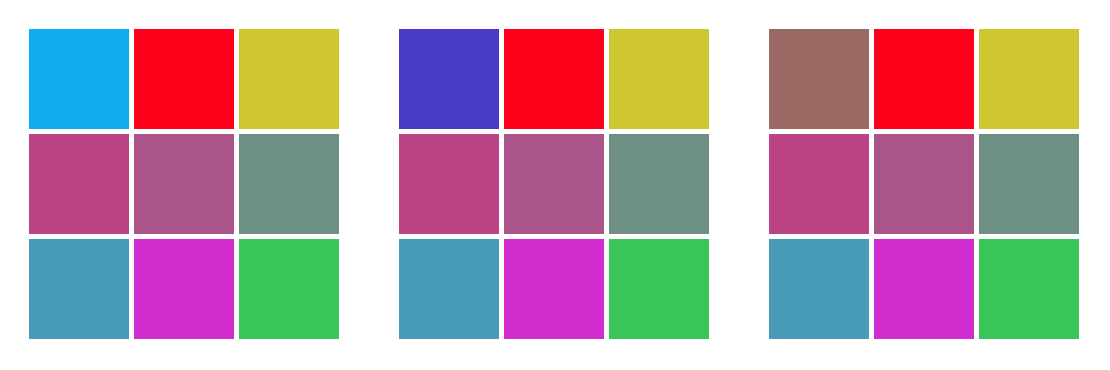

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of three colored blocks arranged in three horizontal rows and three vertical columns, forming a 3x3 grid. The top row contains three squares: the first is a cyan square, the second is a red square, and the third is a gold square. The middle row includes three squares: the first is a maroon square, the second is a green square, and the third is a maroon square. The bottom row features three squares: the first is a teal square, the second is a green square, and the third is a magenta square.
 


Entry 4441


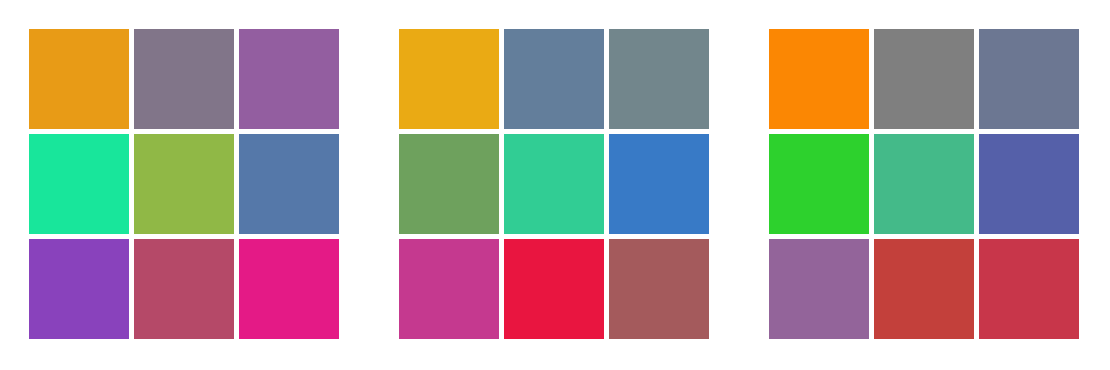

Position described by speaker: left
Response sentence: <think>

</think>

This grid is a 4x4 mosaic of solid-colored squares, each containing a distinct, pure hue. The squares are arranged in a regular 2x2 grid pattern across the image, with each 2x2 block containing four identical squares.

There are 16 squares in total.
The squares are arranged in 2x2 blocks, with each 2x2 block containing four identical squares.

The colors are distinct and solid.
The colors are:
- Orange
- Purple
- Green
- Blue
- Red
- Teal
- Green (appears twice)
- Purple (appears twice)
- Pink (appears twice)
 




In [ ]:
####Qwen3.5-0.8B
print("Qwen3.5-0.8B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-9B thinking off
Entry 2271


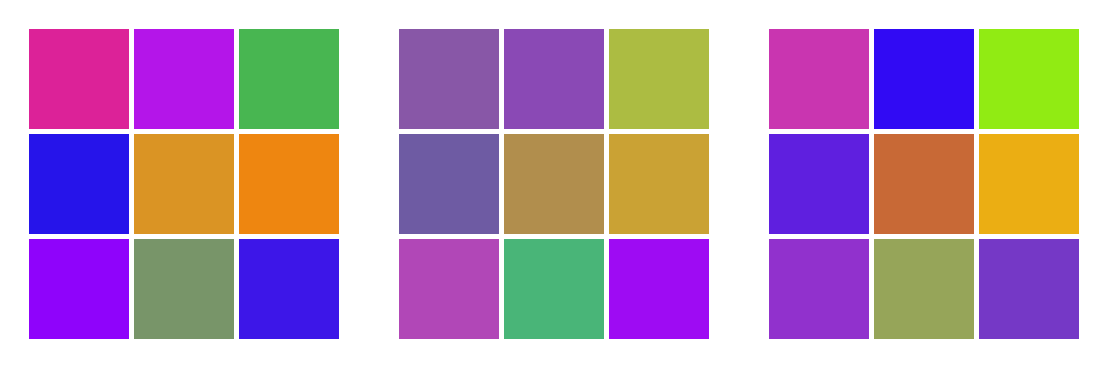

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright magenta square in the top-left corner and a vivid orange square in the center-right position. These two colors are unique to this grid compared to the other two.
 


Entry 8698


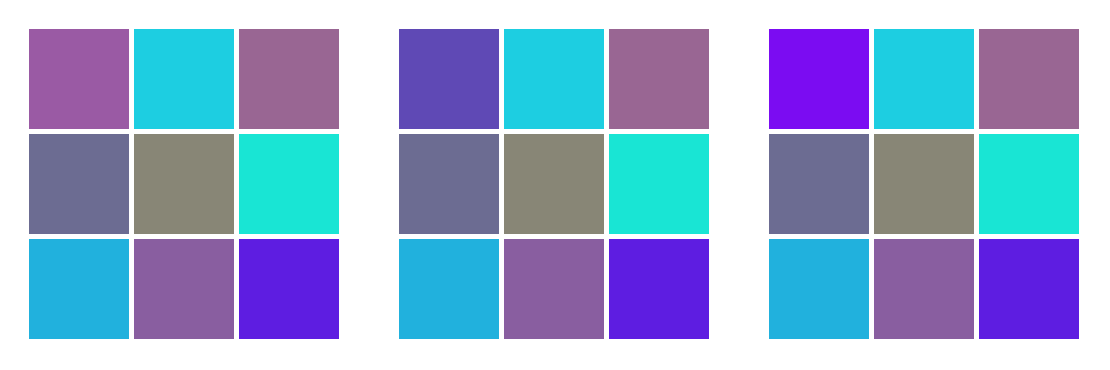

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright purple square in the bottom-right corner, which is more vivid and saturated than the purple squares in the other two grids. Additionally, the top-left square in this grid is a muted lavender-purple, distinct from the deeper violet tones found in the other grids.
 


Entry 3753


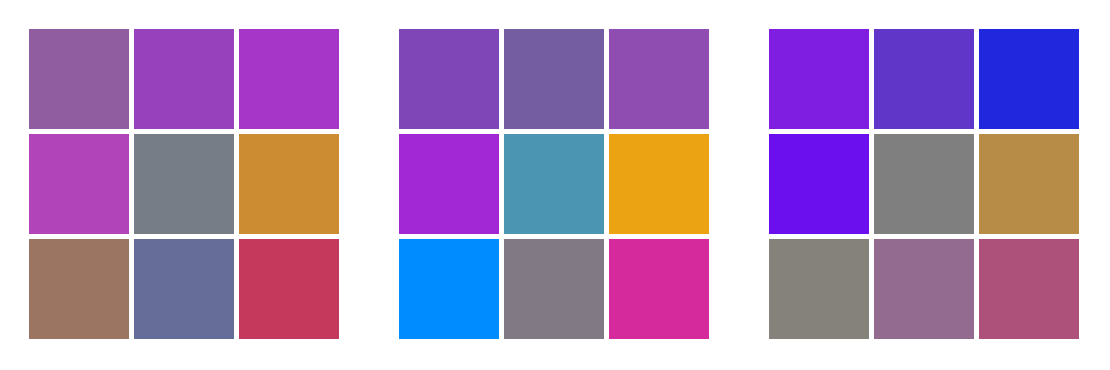

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The right grid contains a bright blue square in the top-right corner, which is not present in the other two grids. Additionally, it includes a vibrant purple square in the middle-left position and a deep magenta square in the bottom-right corner — both of which are unique to this grid compared to the others. These distinct, saturated colors make it easily identifiable.
 


Entry 8665


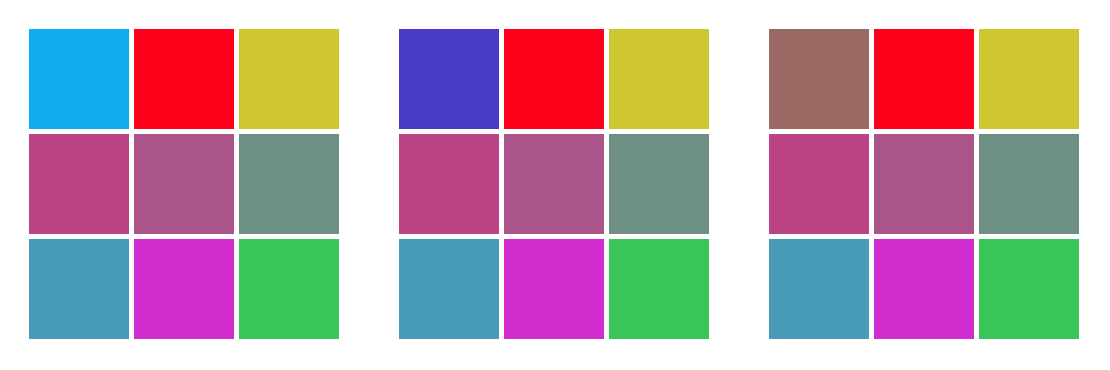

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid is the only one containing a bright cyan square in the top-left corner.
 


Entry 4441


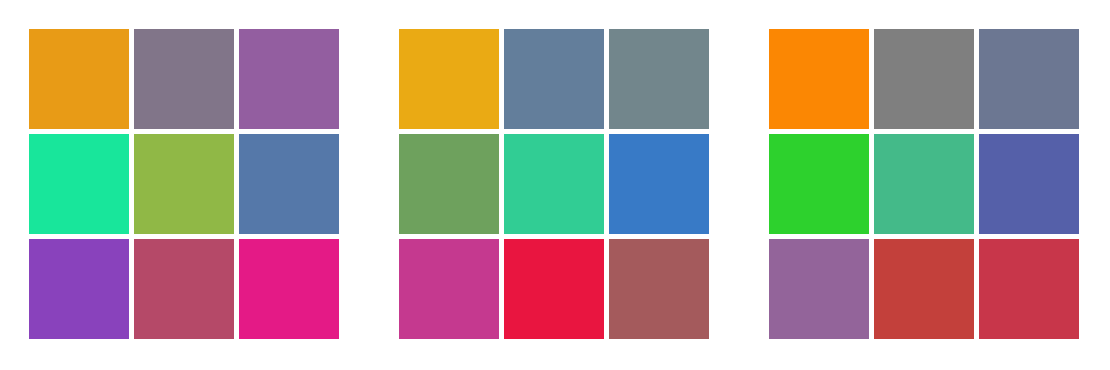

Position described by speaker: left
Response sentence: <think>

</think>

To identify the left grid, focus on these distinctive features:

- The top-left square is a bright, saturated orange (distinctly different from the more muted or yellow-orange tones in the other grids).
- The bottom-left square is a deep purple (not to be confused with the lighter lavender-like purple in the middle grid or the reddish-purple in the right grid).
- The bottom-right square is a vivid magenta/pink — this color does not appear in the other two grids.

These three colors — especially the bright orange at the top-left and the magenta at the bottom-right — are unique to the left grid and will help you pinpoint it.
 




In [7]:
####Qwen3.5-9B
print("Qwen3.5-9B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

In [ ]:
####Molmo2-4B
print("Molmo2-4B")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Entry 46956


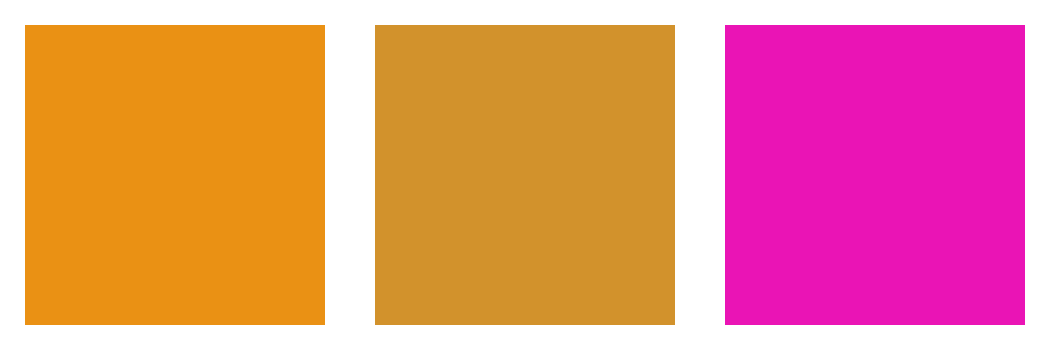

Position described by speaker: left
Response sentence: The defined color is a muted orange. It has a soft, warm tone with subtle gradients and is slightly darker than a standard orange. 


Entry 21163


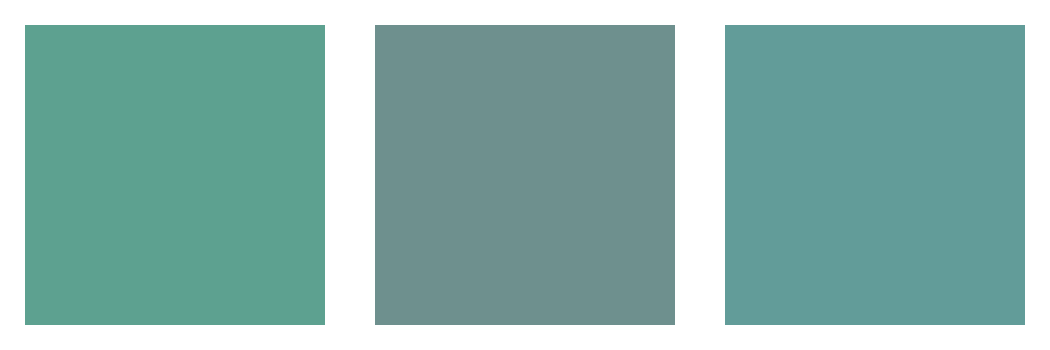

Position described by speaker: middle
Response sentence: The color described as  [[375,25],[675,325]] appears to be a gradient that transitions from a lighter green to a darker green, resembling a transition from a grassy to a forested area. This color is distinctive because it shows a gradual change in hue without any sudden transitions, giving a smooth and natural appearance. 


Entry 38273


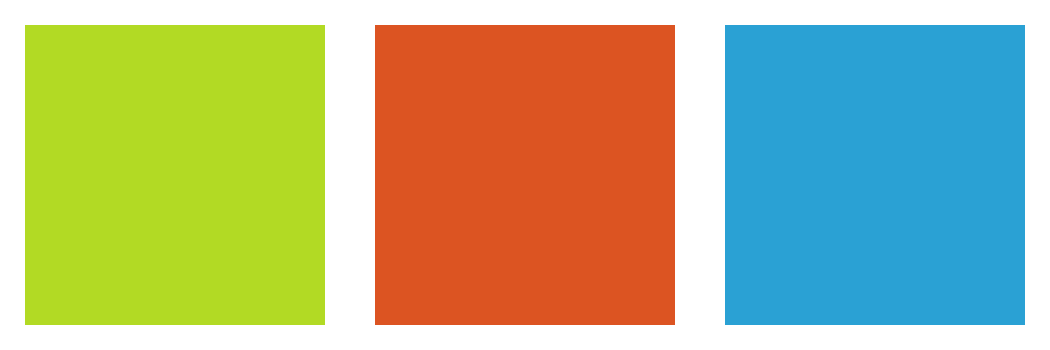

Position described by speaker: right
Response sentence: The color defined by the coordinates [725, 25] to [1025, 325] is a bright yellow-green. This color stands out among the other two colors, which are a warm red-orange and a deep blue. The yellow-green color is bright and vibrant, making it easily distinguishable from the other two colors. 


Entry 31799


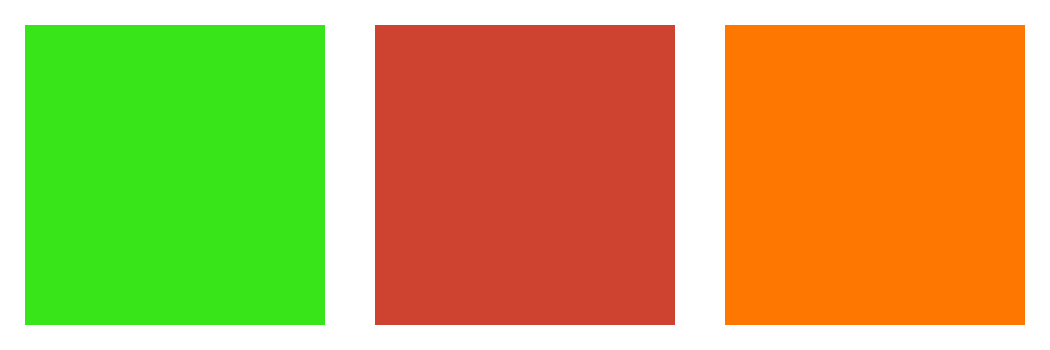

Position described by speaker: middle
Response sentence: The color in the first position is a bright green. It stands out due to its vibrant hue and high saturation. In the second position, the color is a rich red. It has a warm, bold color that sets it apart from the green. In the third position, the color is a bright orange. It is bold and bold, with a strong contrast to the other two colors. 


Entry 45025


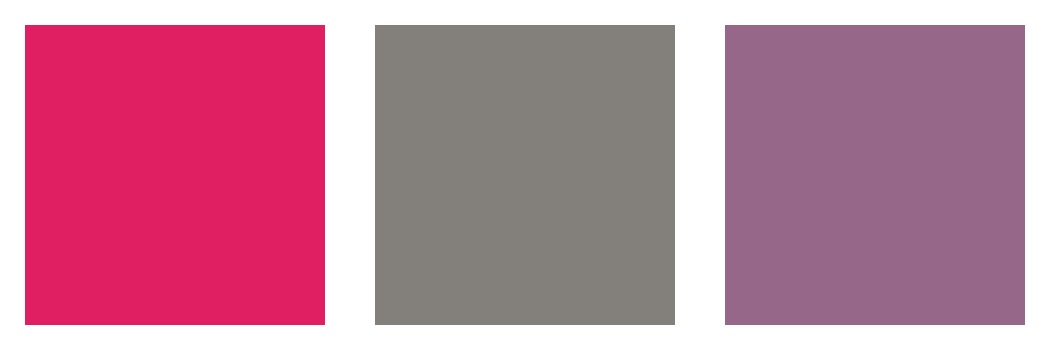

Position described by speaker: right
Response sentence: The color described is a greyish purple. 


Entry 40841


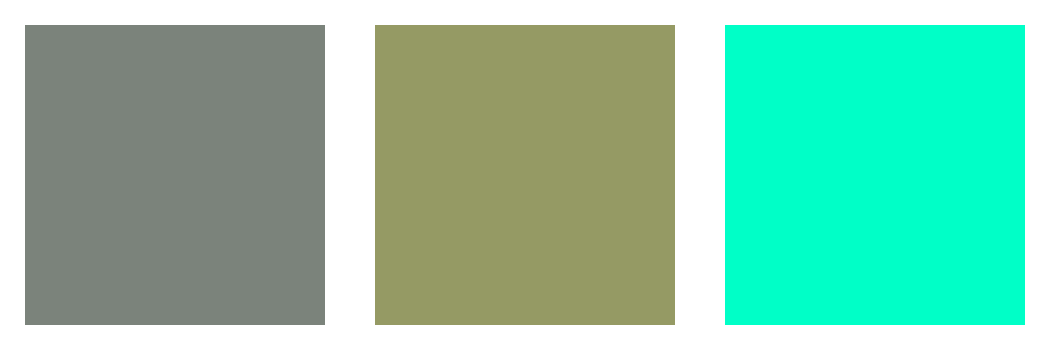

Position described by speaker: right
Response sentence: The color described is a deep, rich green that appears to be a combination of shades of olive green and dark teal. It has a warm, inviting tone and is distinct from the other two colors, which are more muted and earthy in tone. 


Entry 36126


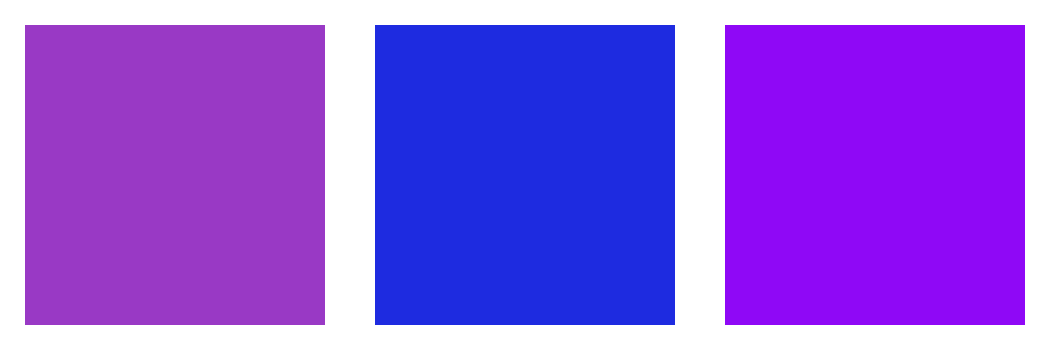

Position described by speaker: middle
Response sentence: The color you described is a shade of blue, specifically a medium shade of deep blue. It has a cool tone and is often associated with trust, reliability, and calmness. It differs from the other two colors by being a darker shade of blue, and it stands out more prominently due to its contrast with the other two colors. 


Entry 13108


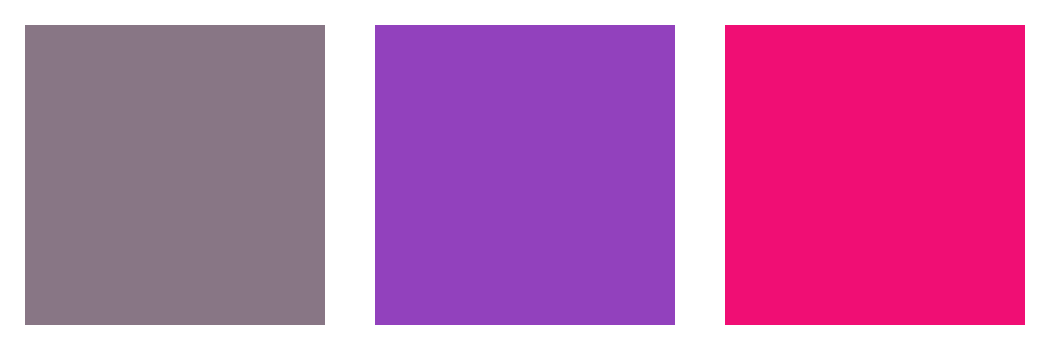

Position described by speaker: right
Response sentence: The color defined by the coordinates [[725,25],[1025,325]] is a vibrant magenta color. It stands out vividly among the other two colors, which are a muted gray and a purplish hue. 


Entry 44344


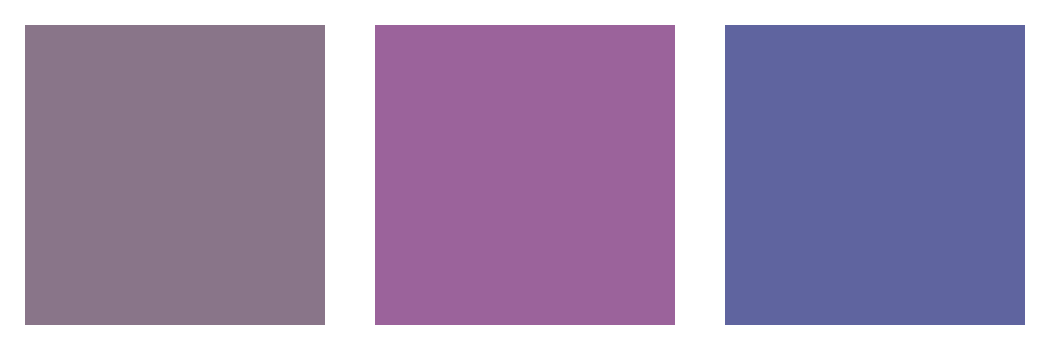

Position described by speaker: right
Response sentence: The color that corresponds to the coordinates [[725,25],[1025,325]] is lavender. This color has a soft, gentle hue with a subtle gradient that transitions from a lighter lavender at the top to a deeper lavender at the bottom. 


Entry 5657


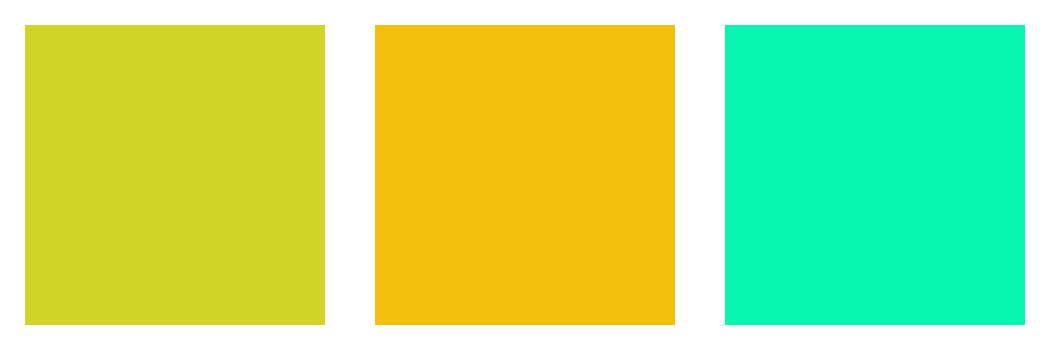

Position described by speaker: middle
Response sentence: The color described as [375,25,675,325] is an orange-yellow hue. 


Entry 46968


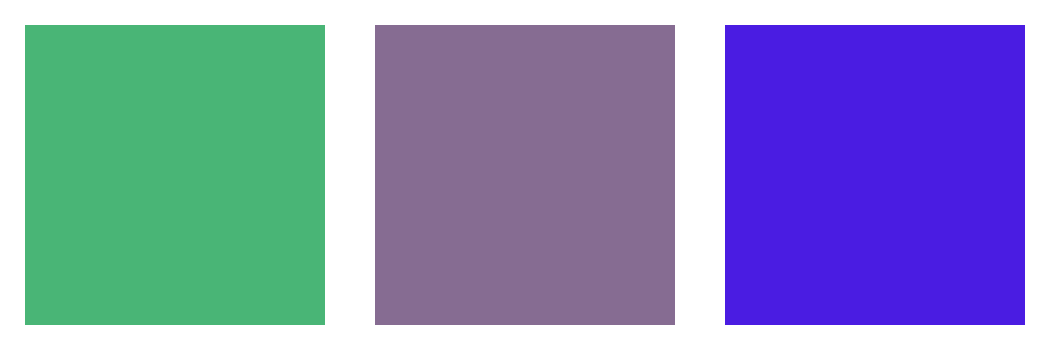

Position described by speaker: middle
Response sentence: The color defined by the coordinates [[375,25],[675,325]] is a deep purple. 


Entry 14976


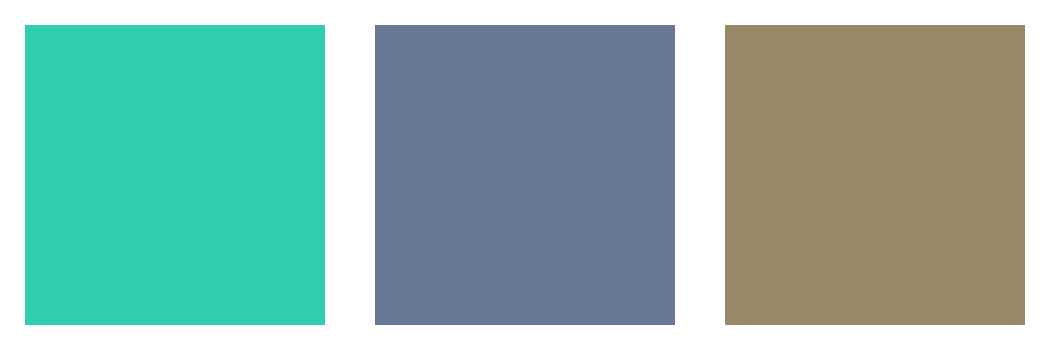

Position described by speaker: middle
Response sentence: The color defined by the coordinates [375, 25, 675, 325] is a medium blue-green shade. 


Entry 5466


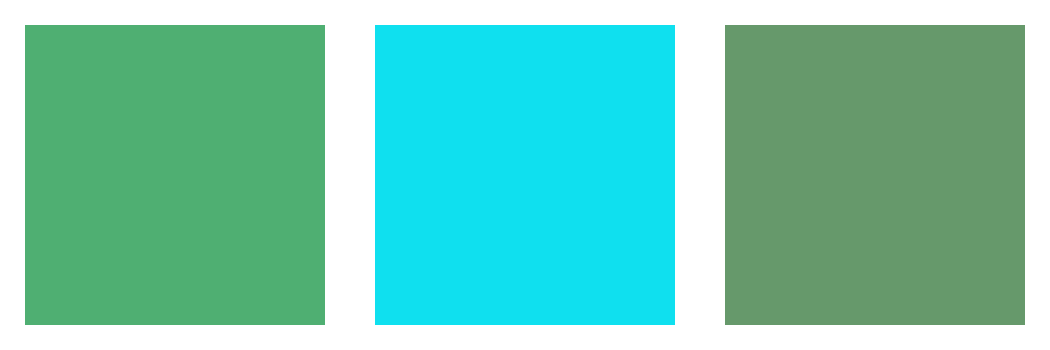

Position described by speaker: left
Response sentence: The color in the specified coordinates is a bright turquoise. It is distinct from the other two colors which are a vibrant green and a muted green. 


Entry 8617


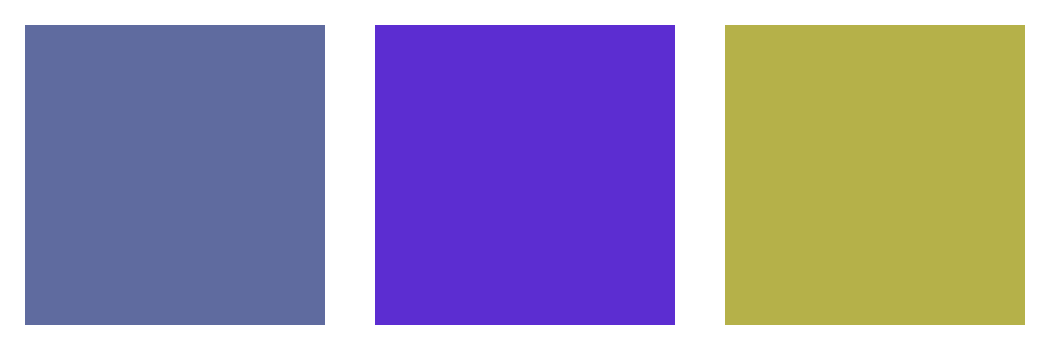

Position described by speaker: left
Response sentence: The color in the coordinates [[25,25],[325,325]] appears to be a soft, muted shade of blue. It has a slight coolness to it, reminiscent of a pastel blue, and it lacks the bright, intense color that other blues usually have. 


Entry 33942


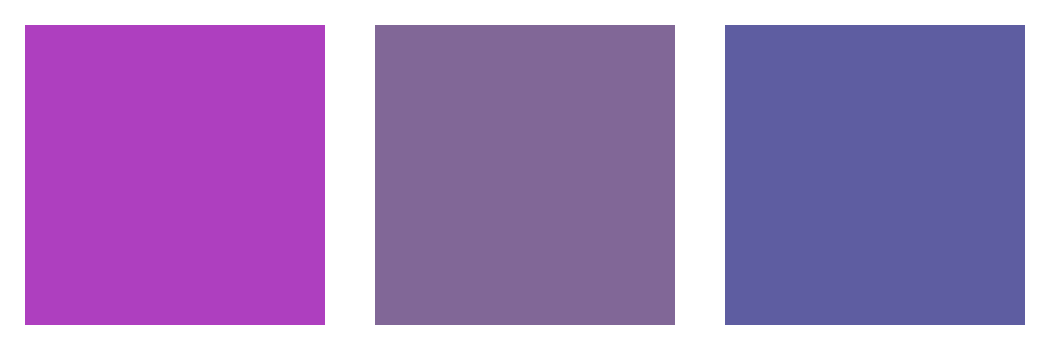

Position described by speaker: left
Response sentence: The needed color is purple. 


Entry 33148


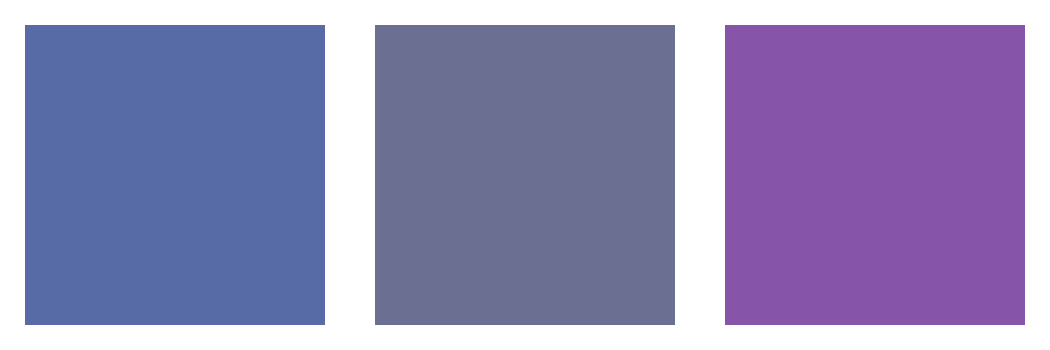

Position described by speaker: middle
Response sentence: The color described is a medium to dark blue. It has a gradient effect that gradually transitions from a lighter shade to a darker shade. The other two colors are a lighter, almost pastel blue and a more vibrant purple. 


Entry 8358


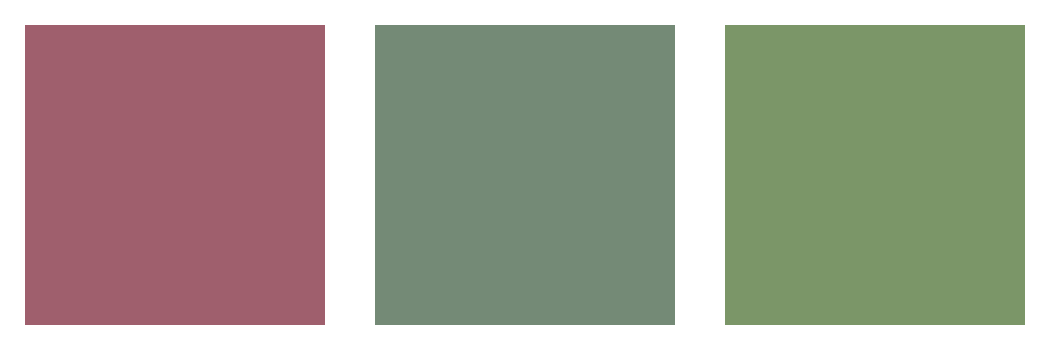

Position described by speaker: right
Response sentence: The color in the specified coordinates is a deep, almost maroon-purple hue, reminiscent of a deep raspberry or deep rose. It has a rich and warm tone, and it stands out as the most vibrant and striking among the three colors in the image. The other two colors are a lighter, more muted shade of green, with one of them appearing to be a pale green and the other a slightly darker shade. 


Entry 17227


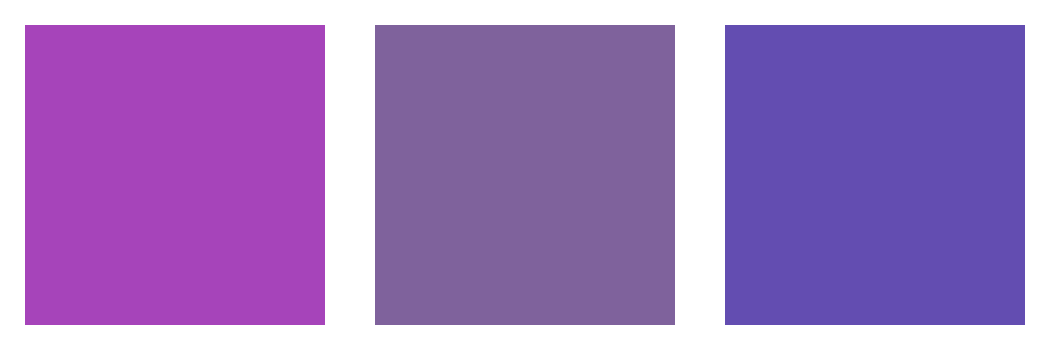

Position described by speaker: middle
Response sentence: The defined color is the one located in the center of the image. It is a medium to dark purple shade, similar in hue to the color in the third square from the right, but with a slightly darker tone. The medium shade of purple is distinct from the left square, which is a vibrant purple, and the right square, which is a very dark purple. 


Entry 40219


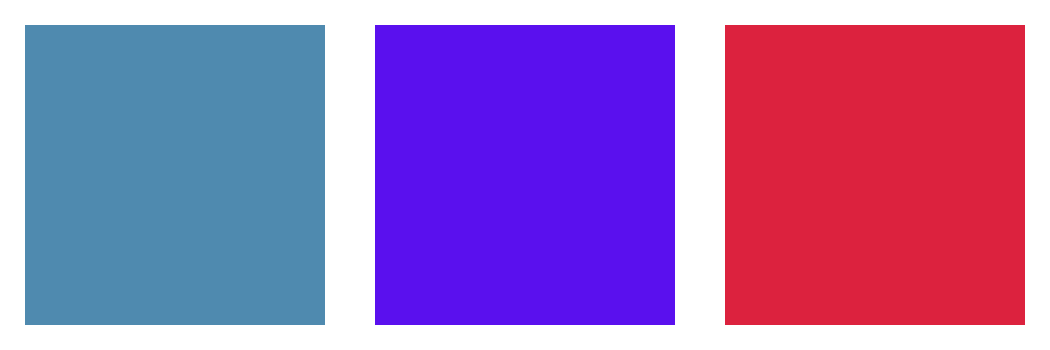

Position described by speaker: left
Response sentence: The defined color is the blue in the middle. It is a cool blue shade that is slightly lighter than a traditional blue color, with a slightly softer and more muted tone. The other colors are more saturated and intense, with the red being the most vibrant and the purple being the second most intense. 


Entry 12708


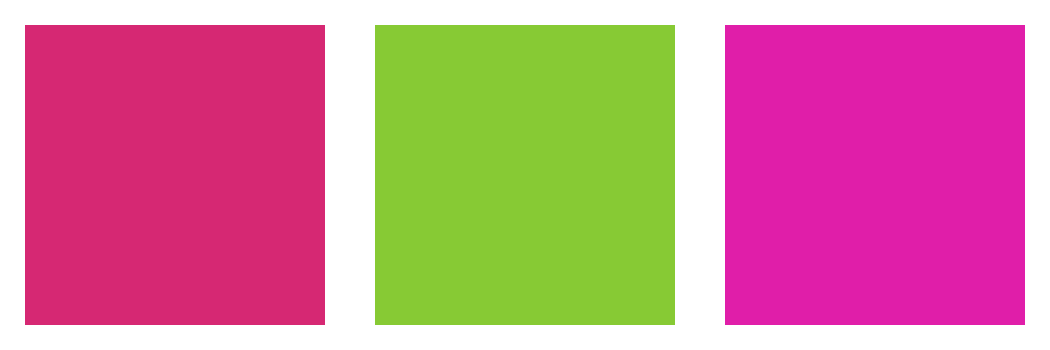

Position described by speaker: right
Response sentence: The color in the coordinates [725, 25] is a light green. It is a vibrant green with a slightly yellowish hue. 


Entry 17531


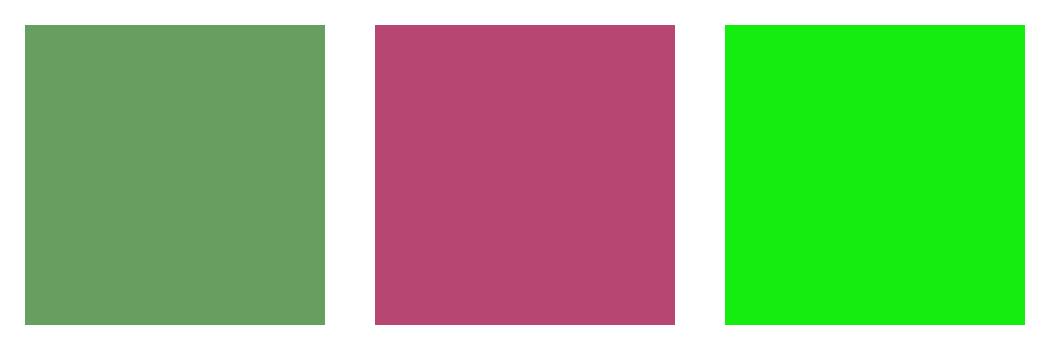

Position described by speaker: left
Response sentence: The color described is green. It is a vibrant shade of green, typical of grass or leaves, with a slightly muted tone that gives it a natural appearance. 


Entry 29205


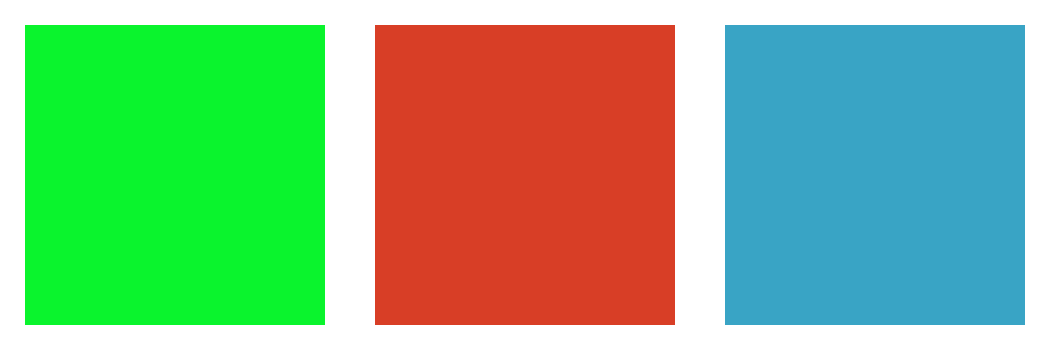

Position described by speaker: left
Response sentence: The color described is a vivid, almost fluorescent green. It stands out due to its bright, almost luminous hue. The other two colors, which are red and blue, have a more subdued and less intense appearance. 


Entry 21406


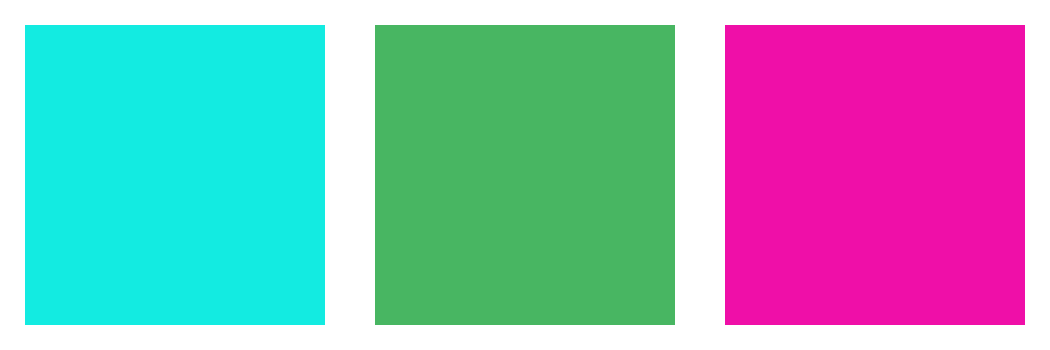

Position described by speaker: middle
Response sentence: The color in the middle, defined by coordinates [[375,25], [675,325]], is a bright green. 


Entry 42193


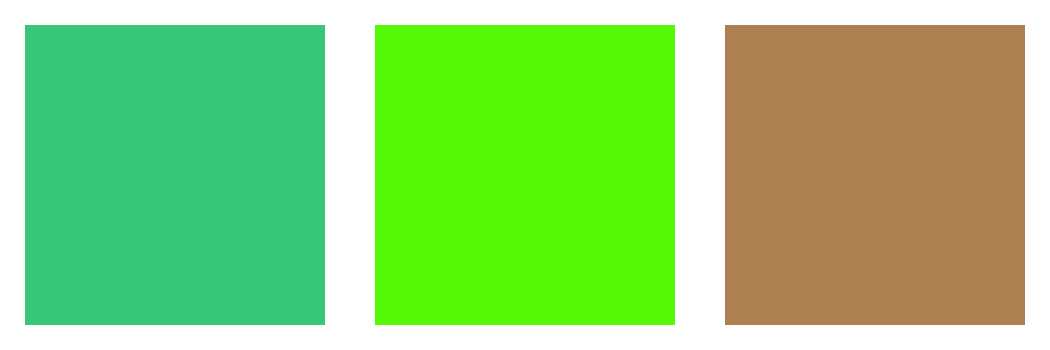

Position described by speaker: middle
Response sentence: The color in the specified coordinates is green. It is a bright, vibrant green with a high saturation and a slight bluish tint. 


Entry 23894


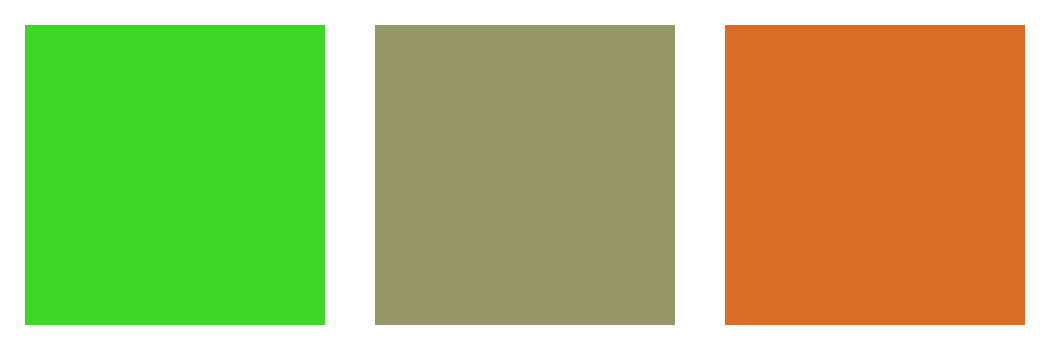

Position described by speaker: middle
Response sentence: The color defined by the coordinates [[375,25], [675,325]] is a muted brownish-gray. It has a neutral, slightly earthy tone and is less vibrant than the bright green or orange colors present in the other two squares. 


Entry 33486


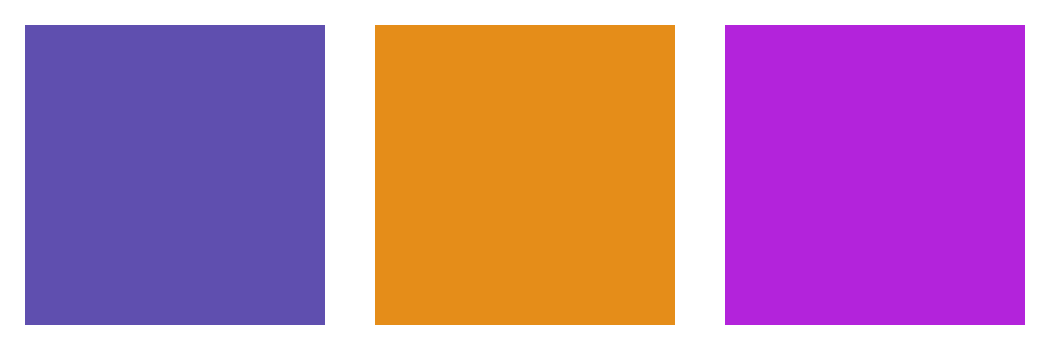

Position described by speaker: right
Response sentence: The color defined by the coordinates [[725,25],[1025,325]] is a vibrant orange. It is distinct from the other two colors because it has a bright and vivid orange hue, with a slight gradient that transitions from a deeper shade at the top to a lighter shade at the bottom. 


Entry 4091


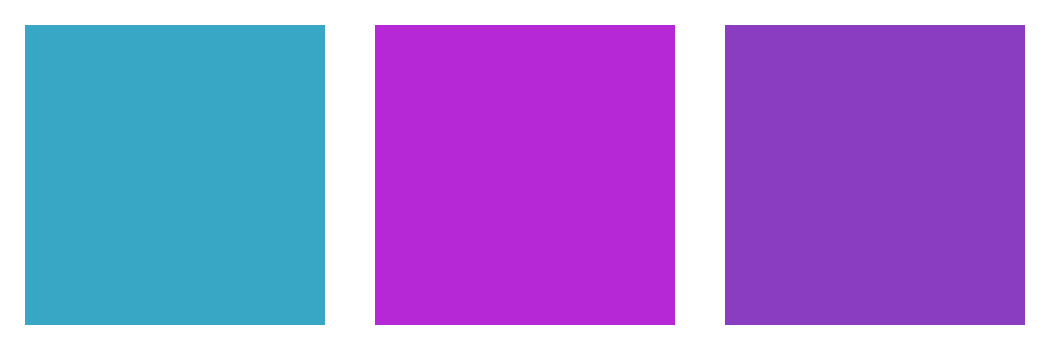

Position described by speaker: right
Response sentence: The defined color is the magenta color. It is distinctive because it stands out against the other two colors, which are turquoise and purple. 


Entry 9194


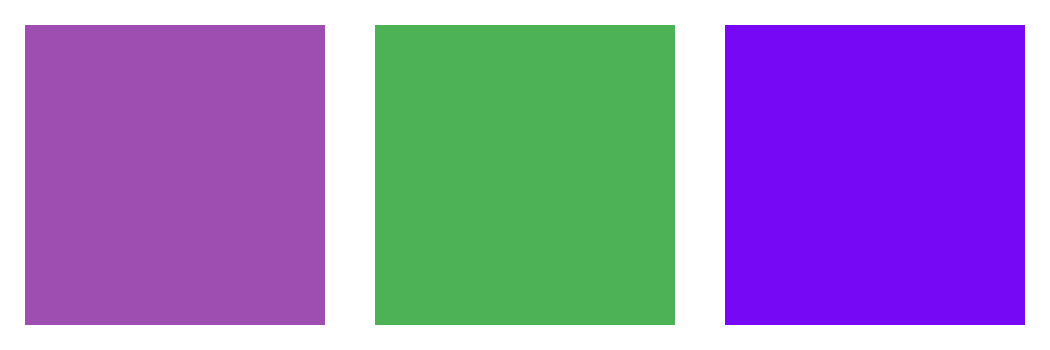

Position described by speaker: left
Response sentence: The color is a vivid purple, which stands out against the white background. 


Entry 26941


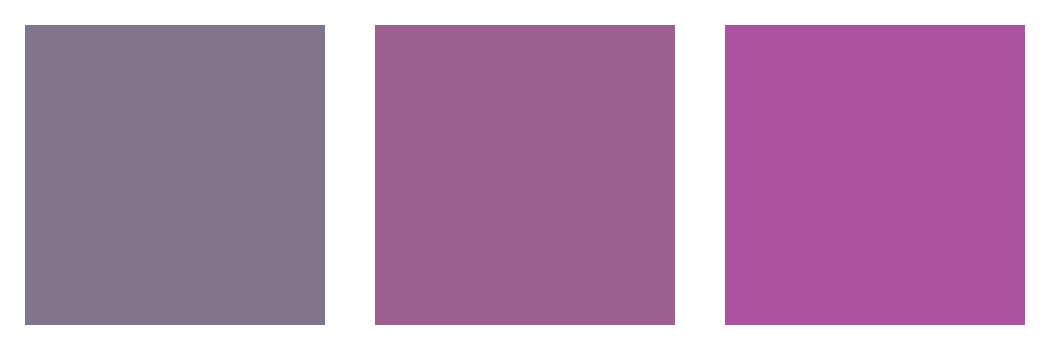

Position described by speaker: middle
Response sentence: The color described is a muted purple. It has a slightly bluish tint and is more towards the left side of the spectrum compared to the other two colors. It is a soft, earthy purple that would complement many other colors without overpowering them. 


Entry 45674


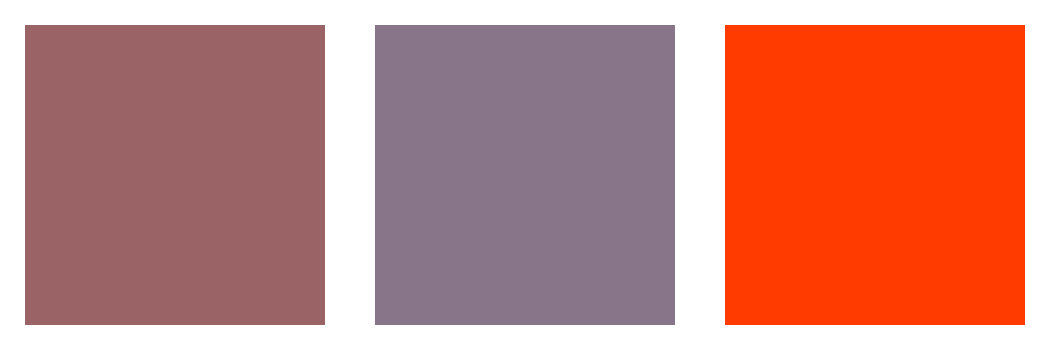

Position described by speaker: middle
Response sentence: The color you are describing is a muted purple, characterized by a blend of warm and cool tones. It has a soft, almost olive-like hue and is more towards the middle of the spectrum compared to the other colors in the image. 




In [32]:
from data_prep.data_utils import build_patch_image_with_target_highlight
import base64
from io import BytesIO
from PIL import Image

html_file = open("generated_responses_patches_qwen2_2B_chatgpt.html", "w", encoding="utf-8")

def write_html(text):
    html_file.write(text + "<br>\n")


old_responses = new_responses
new_responses = []

html_file.write(f"<h1>Model: Qwen2-VL-2B-Instruct</h1>")

positions = list()
entrys = list()
for i, entry in data_df.sample(n=30, random_state=42).iterrows():
    print(f"Entry {i}")
    write_html(f"<b>Entry {i}</b>")
    entrys.append("Entry: " +str(i))

    img = build_patch_image_with_target_highlight(entry.hls_values, entry.s_order_t_distr1_distr2, **img_kwargs, highlight_target=False)
    position = ""
    entry.target = entry.s_order_t_distr1_distr2.index(0)
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    if(entry.s_order_t_distr1_distr2[0] == 0):
        bounding_box ="[[25,25],[325,325]]"
    elif(entry.s_order_t_distr1_distr2[1] == 0):
        bounding_box ="[[375,25],[675,325]]"
    elif(entry.s_order_t_distr1_distr2[2] == 0):
        bounding_box ="[[725,25],[1025,325]]"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, bounding_box, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)

    buffer = BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    write_html(f'<img src="data:image/png;base64,{img_base64}">')

    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")

    positions.append(position)
    #write_html(f"Position described by speaker: {position}")
    write_html(f"{response_sentence}")
    write_html("<hr>")

    new_responses.append(response_sentence)

html_file.close()


##### write html file with target positions
html_file = open("generated_responses_patches_qwen2_2B_chatgpt_solution.html", "w", encoding="utf-8")

html_file.write(f"<h1>Model: Qwen2-VL-2B-Instruct</h1>")

for position, entry in zip(positions, entrys):
    write_html(f"<b>{entry}</b>")
    write_html(f"Position described by speaker: {position}")
    write_html("<hr>")

html_file.close()



In [12]:


for i in range(5):
    if old_responses[i] != new_responses[i]:
        print(f"Response changed for entry {i}")
    else:
        print(f"Response did not change for entry {i}")

Response changed for entry 0
Response changed for entry 1
Response changed for entry 2
Response changed for entry 3
Response changed for entry 4


In [7]:
print(model.model.generation_config)
model.model.generation_config.temperature = 0.7

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.0,
  "temperature": 0.7,
  "top_k": 1,
  "top_p": 0.001
}



In [ ]:


response_sentence = model.generate(
            full_prompt, img, prune_output_to_response=True, **generate_kwargs)